In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [82]:
df = pd.read_csv('housing.csv')

In [83]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [84]:
df.shape

(20640, 10)

In [85]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [86]:
df.sample(4)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12266,-116.89,33.75,23.0,2719.0,538.0,930.0,485.0,2.0154,81700.0,INLAND
12943,-121.27,38.64,22.0,1597.0,280.0,657.0,273.0,4.3098,213500.0,INLAND
7628,-118.28,33.85,27.0,489.0,98.0,403.0,97.0,5.1440,180800.0,<1H OCEAN
6805,-118.10,34.10,41.0,1379.0,315.0,1249.0,309.0,2.6553,183100.0,<1H OCEAN


In [87]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


# EDA

In [88]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [90]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [91]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [92]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### Target Column = median_house_value
### numeric_col = longitude,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
### categorical_col = ocean_proximity 

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# DataVisualization

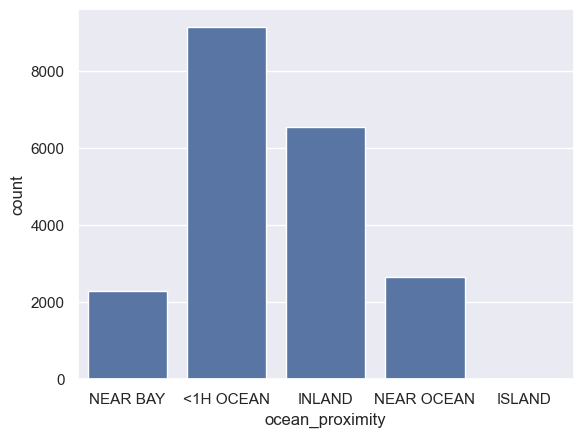

In [95]:
sns.set()
sns.countplot(x = df['ocean_proximity'], data = df)
plt.show()

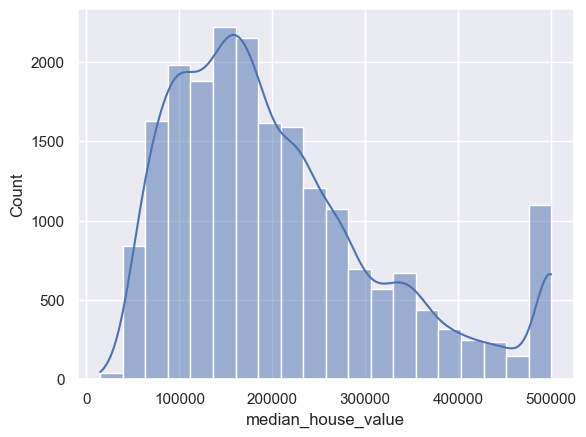

In [96]:
sns.histplot(df['median_house_value'],kde = True,bins = 20 )
plt.show()

<Axes: >

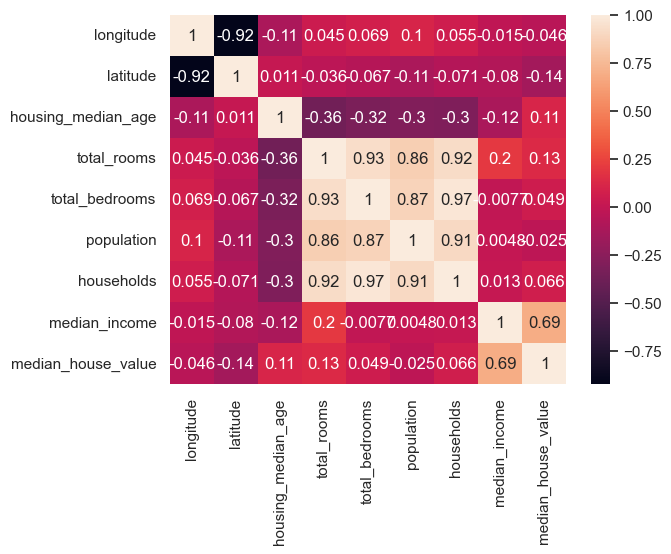

In [97]:
sns.heatmap(df.corr(numeric_only = True), annot = True,cbar = True)

In [98]:
X = df.drop(columns = ['median_house_value','ocean_proximity'],axis = 1)
y = df['median_house_value']

In [99]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462


In [100]:
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [101]:
from sklearn.model_selection import train_test_split

# X represents features, y represents labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)  

In [102]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542
...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192


In [103]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
20046,-119.01,36.06,25.0,1505.0,537.870553,1392.0,359.0,1.6812
3024,-119.46,35.14,30.0,2943.0,537.870553,1565.0,584.0,2.5313
15663,-122.44,37.80,52.0,3830.0,537.870553,1310.0,963.0,3.4801
20484,-118.72,34.28,17.0,3051.0,537.870553,1705.0,495.0,5.7376
9814,-121.93,36.62,34.0,2351.0,537.870553,1063.0,428.0,3.7250
...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.000000,1351.0,452.0,4.6050
16623,-120.83,35.36,28.0,4323.0,886.000000,1650.0,705.0,2.7266
18086,-122.05,37.31,25.0,4111.0,538.000000,1585.0,568.0,9.2298
2144,-119.76,36.77,36.0,2507.0,466.000000,1227.0,474.0,2.7850


In [104]:
y_train

14196    103000.0
8267     382100.0
17445    172600.0
14265     93400.0
2271      96500.0
           ...   
11284    229200.0
11964     97800.0
5390     222100.0
860      283500.0
15795    325000.0
Name: median_house_value, Length: 16512, dtype: float64

In [105]:
y_test

20046     47700.0
3024      45800.0
15663    500001.0
20484    218600.0
9814     278000.0
           ...   
15362    263300.0
16623    266800.0
18086    500001.0
2144      72300.0
3665     151500.0
Name: median_house_value, Length: 4128, dtype: float64

# Feature selection

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [107]:
X_train_scaled

array([[ 1.27258656, -1.3728112 ,  0.34849025, ...,  0.76827628,
         0.32290591, -0.326196  ],
       [ 0.70916212, -0.87669601,  1.61811813, ..., -0.09890135,
         0.6720272 , -0.03584338],
       [-0.44760309, -0.46014647, -1.95271028, ..., -0.44981806,
        -0.43046109,  0.14470145],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ...,  0.28983345,
         0.07090859, -0.49697313],
       [-1.18553953,  0.90651045, -1.07984112, ...,  0.30830275,
         0.15490769,  0.96545045],
       [-1.41489815,  0.99543676,  1.85617335, ...,  1.04883375,
         1.94776365, -0.68544764]], shape=(16512, 8))

In [108]:
X_test_scaled

array([[ 0.28534728,  0.1951    , -0.28632369, ..., -0.03030109,
        -0.37008673, -1.15508475],
       [ 0.06097472, -0.23549054,  0.11043502, ...,  0.12185077,
         0.220532  , -0.70865905],
       [-1.42487026,  1.00947776,  1.85617335, ..., -0.10241931,
         1.21539643, -0.21040155],
       ...,
       [-1.23041404,  0.78014149, -0.28632369, ...,  0.13944058,
         0.17853244,  2.80902421],
       [-0.08860699,  0.52740357,  0.58654547, ..., -0.17541702,
        -0.06821494, -0.57542978],
       [ 0.60445493, -0.66608108, -0.92113763, ...,  0.21507676,
        -0.13646421, -0.17259111]], shape=(4128, 8))

# Ready for Model Selection

### pip install catboost lightgbm

In [114]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [115]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        random_state=42,
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        random_state=42
    ),
    "CatBoost": CatBoostRegressor(
        verbose=0,
        random_state=42
    ),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()

}

# Train and Evaluate Every Model

In [116]:
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Prediction
    y_pred = model.predict(X_test)
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    # Adjusted R²
    n = X_test.shape[0]
    p = X_test.shape[1]
    adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2,
        adj_r2
    ])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 207194.693738


# Create Results Table

In [117]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "Adjusted R2"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)
results_df.reset_index(drop=True, inplace=True)

print(results_df)

                Model           MAE           MSE           RMSE  R2 Score  \
0            CatBoost  30577.262743  2.130269e+09   46154.833918  0.837435   
1             XGBoost  32456.550116  2.352167e+09   48499.144289  0.820501   
2            LightGBM  32654.273681  2.353282e+09   48510.641486  0.820416   
3       Random Forest  32180.606616  2.495746e+09   49957.438998  0.809545   
4   Gradient Boosting  38115.135433  3.116334e+09   55824.130412  0.762186   
5       Decision Tree  44355.036579  4.891041e+09   69935.978485  0.626755   
6    Ridge Regression  51835.543199  5.052927e+09   71083.945634  0.614401   
7    Lasso Regression  51835.656767  5.052943e+09   71084.052853  0.614400   
8   Linear Regression  51835.734726  5.052954e+09   71084.131168  0.614399   
9          ElasticNet  54591.856795  5.398096e+09   73471.737313  0.588060   
10                KNN  78354.692393  1.016972e+10  100845.032180  0.223928   
11                SVR  87341.414570  1.374128e+10  117223.198165

In [118]:
# Best Model
best_model = results_df.iloc[0]
print(best_model)

Model                   CatBoost
MAE                 30577.262743
MSE            2130268694.028037
RMSE                46154.833918
R2 Score                0.837435
Adjusted R2             0.837119
Name: 0, dtype: object
